# Lab 8: Define and Solve an ML Problem of Your Choosing

In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

In this lab assignment, you will follow the machine learning life cycle and implement a model to solve a machine learning problem of your choosing. You will select a data set and choose a predictive problem that the data set supports.  You will then inspect the data with your problem in mind and begin to formulate a  project plan. You will then implement the machine learning project plan. 

You will complete the following tasks:

1. Build Your DataFrame
2. Define Your ML Problem
3. Perform exploratory data analysis to understand your data.
4. Define Your Project Plan
5. Implement Your Project Plan:
    * Prepare your data for your model.
    * Fit your model to the training data and evaluate your model.
    * Improve your model's performance.

## Part 1: Build Your DataFrame

You will have the option to choose one of four data sets that you have worked with in this program:

* The "census" data set that contains Census information from 1994: `censusData.csv`
* Airbnb NYC "listings" data set: `airbnbListingsData.csv`
* World Happiness Report (WHR) data set: `WHR2018Chapter2OnlineData.csv`
* Book Review data set: `bookReviewsData.csv`

Note that these are variations of the data sets that you have worked with in this program. For example, some do not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for each of the four data sets available to you.

<b>Task:</b> In the code cell below, use the same method you have been using to load the data using `pd.read_csv()` and save it to DataFrame `df`. 

You can load each file as a new DataFrame to inspect the data before choosing your data set.

In [2]:
# File names of the four data sets
adultDataSet_filename = os.path.join(os.getcwd(), "data", "censusData.csv")
airbnbDataSet_filename = os.path.join(os.getcwd(), "data", "airbnbListingsData.csv")
WHRDataSet_filename = os.path.join(os.getcwd(), "data", "WHR2018Chapter2OnlineData.csv")
bookReviewDataSet_filename = os.path.join(os.getcwd(), "data", "bookReviewsData.csv")


df = pd.read_csv(bookReviewDataSet_filename)

df.head()

,Review,Positive Review
0,This was perhaps the best of Johannes Steinhof...,True
1,This very fascinating book is a story written ...,True
2,The four tales in this collection are beautifu...,True
3,The book contained more profanity than I expec...,False
4,We have now entered a second time of deep conc...,True


## Part 2: Define Your ML Problem

Next you will formulate your ML Problem. In the markdown cell below, answer the following questions:

1. List the data set you have chosen.
2. What will you be predicting? What is the label?
3. Is this a supervised or unsupervised learning problem? Is this a clustering, classification or regression problem? Is it a binary classificaiton or multi-class classifiction problem?
4. What are your features? (note: this list may change after your explore your data)
5. Explain why this is an important problem. In other words, how would a company create value with a model that predicts this label?

I chose the book reviews dataset, aiming to predict if a book review has a positive sentiment or not. Therefore, the label would be 'Positive Review'. This is a supervised learning problem that is considered a binary classification problem since we are predicting a true or false value. The only other column would be my feature: the 'review' column. This problem is valuable people look for book recommendations when deciding what to buy next, and the bookstores themselves would prefer more favorable books as well. Not to mention, I'm sure an author would appreciate knowing if their book was well liked or not. A company could use a model that predicts a positive sentiment to find out which books they should keep restocking in order to keep their sales up.

## Part 3: Understand Your Data

The next step is to perform exploratory data analysis. Inspect and analyze your data set with your machine learning problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * addressing missingness, such as replacing missing values with means
    * finding and replacing outliers
    * renaming features and labels
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * performing specific data cleaning and preprocessing techniques for an NLP problem
    * addressing class imbalance in your data sample to promote fair AI
    

2. What machine learning model (or models) you would like to use that is suitable for your predictive problem and data?
    * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 
 
3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics and methods that are appropriate for your model?
    

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. If you are working on a classification problem, use techniques you have learned to determine if there is class imbalance.

<b>Task</b>: Use the techniques you have learned in this course to inspect and analyze your data. You can import additional packages that you have used in this course that you will need to perform this task.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-drown menu.

In [3]:
df.shape

(1973, 2)

In [4]:
df.describe()

,Review,Positive Review
count,1973,1973
unique,1865,2
top,I have read several of Hiaasen's books and lov...,False
freq,3,993


In [5]:
df.head()

,Review,Positive Review
0,This was perhaps the best of Johannes Steinhof...,True
1,This very fascinating book is a story written ...,True
2,The four tales in this collection are beautifu...,True
3,The book contained more profanity than I expec...,False
4,We have now entered a second time of deep conc...,True


In [6]:
#check datatypes
df.dtypes

Review             object
Positive Review      bool
dtype: object

False    993
True     980
Name: Positive Review, dtype: int64
False    53.243968
True     52.546917
Name: Positive Review, dtype: float64


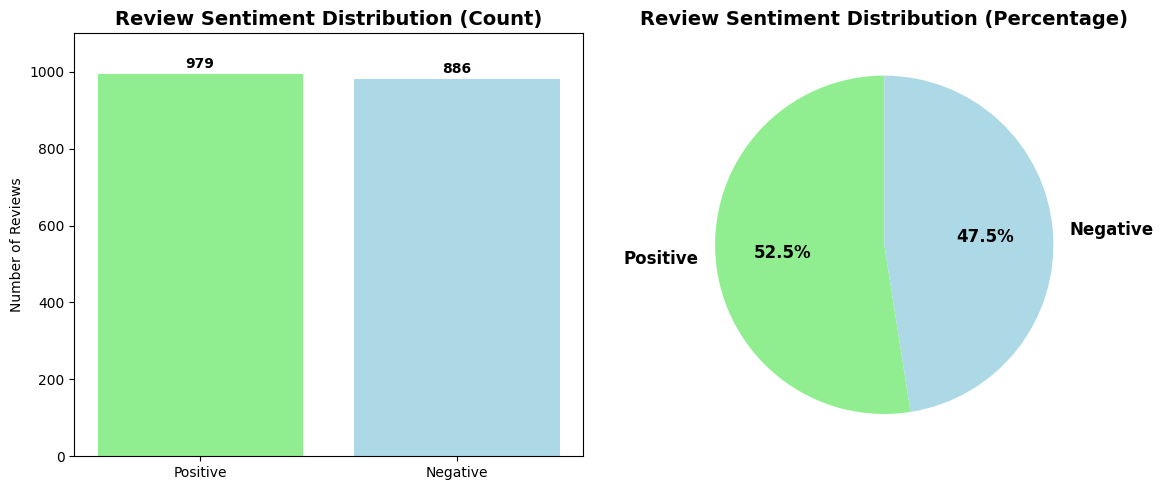

In [7]:
#identify possible class imbalance
class_counts = df['Positive Review'].value_counts()
print(class_counts)

class_percentages = (class_counts/1865)*100
print(class_percentages)

#visualize

#barplot
labels = ['Positive', 'Negative']
colors = ['lightgreen', 'lightblue']
counts = [979, 886]
percentages = [52.49, 47.51]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#barplot with numbers
bar1 = ax1.bar(labels, class_counts, color=colors)
ax1.set_title('Review Sentiment Distribution (Count)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Reviews')
ax1.set_ylim(0, 1100)
#add count labels
for bar, count in zip(bar1, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             str(count), ha='center', va='bottom', fontweight='bold')

# pie chart with percentages
ax2.pie(percentages, labels=labels, colors=colors, autopct='%1.1f%%', 
        startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Review Sentiment Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
#review length character distribution
review_sizes = df['Review'].str.len()

df['Review Length'] = review_sizes
df.head()

,Review,Positive Review,Review Length
0,This was perhaps the best of Johannes Steinhof...,True,503
1,This very fascinating book is a story written ...,True,1436
2,The four tales in this collection are beautifu...,True,428
3,The book contained more profanity than I expec...,False,172
4,We have now entered a second time of deep conc...,True,2209


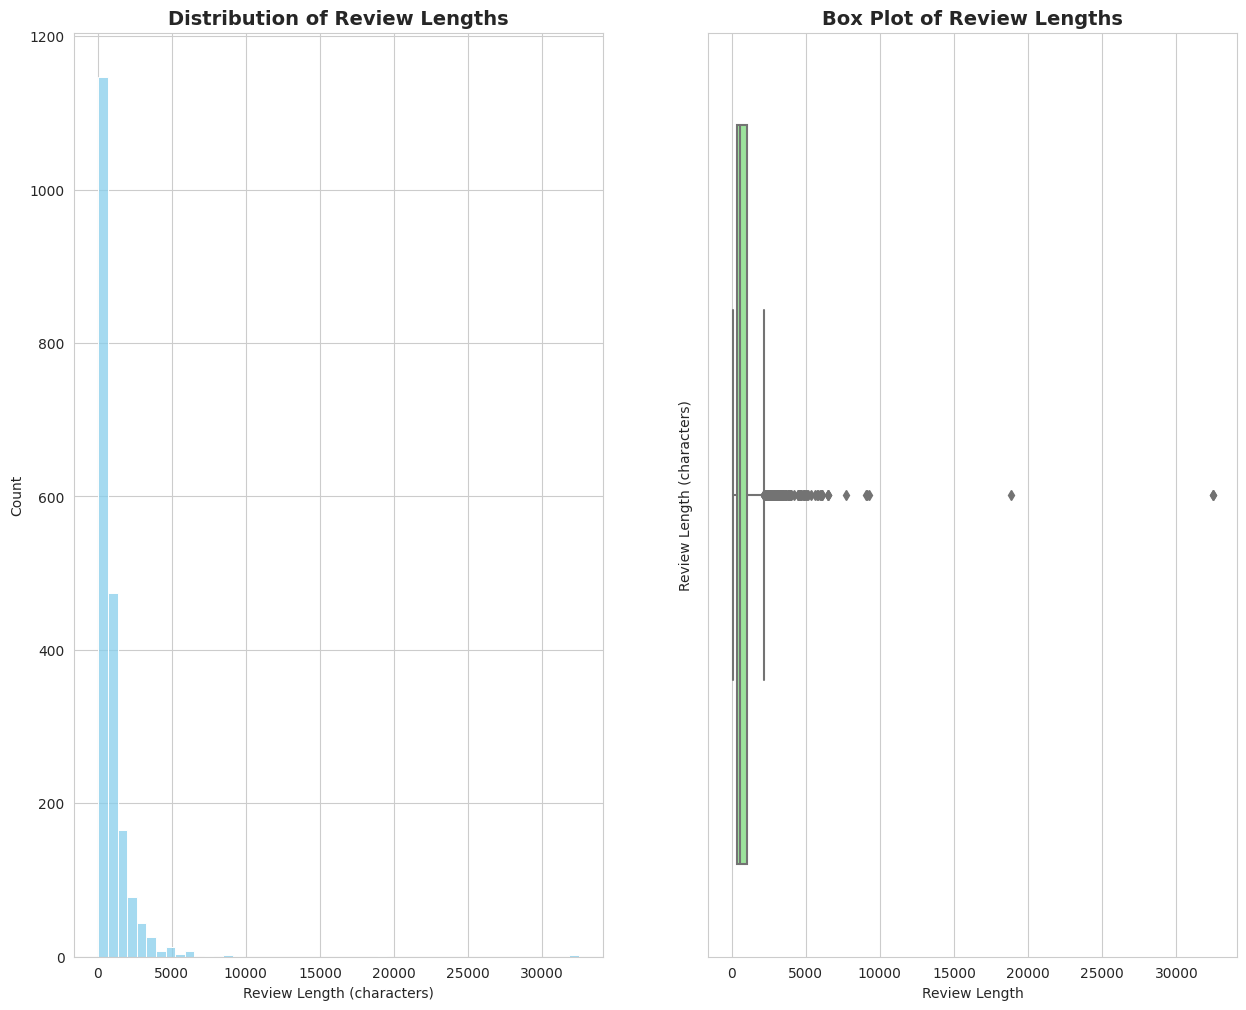

In [9]:
#visualize
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 12))

#histogram
chart1 = sns.histplot(data=df, x='Review Length', bins=50, color='skyblue', ax=axes[0])
chart1.set_title('Distribution of Review Lengths', fontsize=14, fontweight='bold')
chart1.set_xlabel('Review Length (characters)')

#boxplot
chart2 = sns.boxplot(data=df, x='Review Length', color='lightgreen', ax=axes[1])
chart2.set_title('Box Plot of Review Lengths', fontsize=14, fontweight='bold')
chart2.set_ylabel('Review Length (characters)')

plt.show()

In [10]:
print("Review Length Statistics:")
print(f"Total reviews: {len(review_sizes)}")
print(f"Mean length: {np.mean(review_sizes):.1f} characters")
print(f"Median length: {np.median(review_sizes):.1f} characters")
print(f"Standard deviation: {np.std(review_sizes):.1f} characters")
print(f"Minimum length: {np.min(review_sizes)} characters")
print(f"Maximum length: {np.max(review_sizes)} characters")

Review Length Statistics:
Total reviews: 1973
Mean length: 933.3 characters
Median length: 586.0 characters
Standard deviation: 1449.8 characters
Minimum length: 59 characters
Maximum length: 32467 characters


In [11]:
# identify outliers and short/long reviews
q1 = np.percentile(review_sizes, 25)
q3 = np.percentile(review_sizes, 75)
iqr = q3 - q1
upper_bound = q3 + (1.5 * iqr)

outliers = [x for x in review_sizes if x > upper_bound]
print(f'There are {len(outliers)} outliers (above {upper_bound} characters)')

short_reviews = [x for x in review_sizes if x < 100]
print(f'There are {len(short_reviews)} short reviews to be truncated (below 100 characters)')

long_reviews = [x for x in review_sizes if x > 5000]
print(f'There are {len(long_reviews)} very long reviews to be truncated (above 5000 characters)')

There are 162 outliers (above 2166.0 characters)
There are 47 short reviews to be truncated (below 100 characters)
There are 20 very long reviews to be truncated (above 5000 characters)


# Part 4: Define Your Project Plan

Now that you understand your data, in the markdown cell below, define your plan to implement the remaining phases of the machine learning life cycle (data preparation, modeling, evaluation) to solve your ML problem. Answer the following questions:

* Do you have a new feature list? If so, what are the features that you chose to keep and remove after inspecting the data? 
* Explain different data preparation techniques that you will use to prepare your data for modeling.
* What is your model (or models)?
* Describe your plan to train your model, analyze its performance and then improve the model. That is, describe your model building, validation and selection plan to produce a model that generalizes well to new data. 

<Double click this Markdown cell to make it editable, and record your answers here.>

## Part 5: Implement Your Project Plan

<b>Task:</b> In the code cell below, import additional packages that you have used in this course that you will need to implement your project plan.

In [12]:
# YOUR CODE HERE
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2" # suppress info and warning messages
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow.keras as keras
import time
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re
from tensorflow.keras import regularizers

In [13]:
#finding duplicate reviews
dup_count = df['Review'].value_counts()
duplicates = dup_count[dup_count>1]
duplicates

I have read several of Hiaasen's books and loved them.  They were very funny.  This one is not.  It is an endless description of naked strippers.  I found the main character, Erin, to be very unappealing.  She is just so stupid.  Her problems are all of her own creation.  And she is not funny.  I think you have to be a man to like this book.  I, as a woman, just found it exceedingly boring.  I kept waiting for it to get funny.  It never did\n                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [14]:
#removing duplicate reviews 
df = df.drop_duplicates(subset=['Review'])
dup_count = df['Review'].value_counts()
duplicates = dup_count[dup_count>1]
duplicates

Series([], Name: Review, dtype: int64)

In [15]:
#check for null values
nan_count = df.isnull().sum()
nan_count

Review             0
Positive Review    0
Review Length      0
dtype: int64

In [16]:
df[['Positive Review', 'Review']].describe()

,Positive Review,Review
count,1865,1865
unique,2,1865
top,True,This was perhaps the best of Johannes Steinhof...
freq,979,1


In [17]:
#removing short/long reviews
min = 100
max = 5000

df = df[(df['Review Length'] >= min) & (df['Review Length'] <= max)].reset_index(drop=True)
df

,Review,Positive Review,Review Length
0,This was perhaps the best of Johannes Steinhof...,True,503
1,This very fascinating book is a story written ...,True,1436
2,The four tales in this collection are beautifu...,True,428
3,The book contained more profanity than I expec...,False,172
4,We have now entered a second time of deep conc...,True,2209
...,...,...,...
1797,"As a boy, I was fascinated by looking at all o...",True,404
1798,I purchased the book with the intention of tea...,True,558
1799,I am thilled to see this book being available ...,True,679
1800,As many have stated before me the book starts ...,False,349


True     944
False    858
Name: Positive Review, dtype: int64
True     52.386238
False    47.613762
Name: Positive Review, dtype: float64


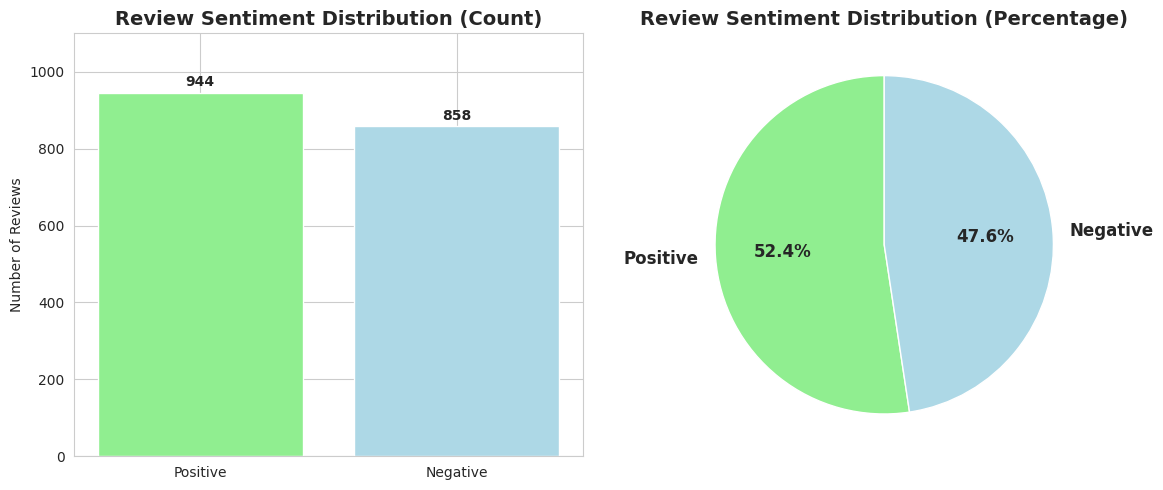

In [18]:
#checking for possible new class imbalance
class_counts = df['Positive Review'].value_counts()
print(class_counts)

class_percentages = (class_counts/1802)*100
print(class_percentages)

#visualize

#barplot
labels = ['Positive', 'Negative']
colors = ['lightgreen', 'lightblue']
counts = [944, 858]
percentages = [52.39, 47.61]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#barplot with numbers
bar1 = ax1.bar(labels, class_counts, color=colors)
ax1.set_title('Review Sentiment Distribution (Count)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Reviews')
ax1.set_ylim(0, 1100)
#add count labels
for bar, count in zip(bar1, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             str(count), ha='center', va='bottom', fontweight='bold')

# pie chart with percentages
ax2.pie(percentages, labels=labels, colors=colors, autopct='%1.1f%%', 
        startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Review Sentiment Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
#remove stopwords for sentiment analysis
def stopwords():
    #sklearn stopwords
    skl_sw = set(ENGLISH_STOP_WORDS)
    #print(f'Sklearn has {len(skl_sw)} stopwords')
    #book stopwords
    book_sw = {
        'book', 'books', 'read', 'reading', 'author', 'writer', 'story', 'stories',
        'chapter', 'chapters', 'page', 'pages', 'novel', 'character', 'characters',
        'plot', 'writing', 'written', 'reader', 'publish', 'published', 'edition',
        'series', 'volume', 'part', 'review', 'recommend', 'recommendation'}
    #filler words
    fillers = {'really', 'actually', 'basically', 'literally', 'obviously', 'definitely',
        'probably', 'perhaps', 'maybe', 'quite', 'rather', 'pretty', 'fairly',
        'somewhat', 'kind', 'sort', 'thing', 'things', 'stuff', 'way', 'ways'}
    all_sw = skl_sw | book_sw| fillers
    print(f'There are {len(all_sw)} stopwords')
    return list(all_sw)

custom_stops = stopwords()

There are 364 stopwords


In [20]:
# YOUR CODE HERE
X = df['Review']
y = df['Positive Review']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 1234)
print(X_train.shape)
print(X_test.shape)

(1351,)
(451,)


In [71]:
#tf-idf vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words=custom_stops, lowercase=True, ngram_range=(1,2),
                                  max_features=2000, min_df=5, max_df=0.8, sublinear_tf=True)
tfidf_vectorizer.fit(X_train)
X_train_tfidf = tfidf_vectorizer.transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [72]:
vocabulary_size = len(tfidf_vectorizer.vocabulary_)
vocabulary_size

2000

In [73]:
# NN
nn_model = keras.Sequential()

# 2. Create the input layer and add it to the model object: 
# YOUR CODE HERE
nn_model.add(keras.layers.InputLayer(input_shape = vocabulary_size))

# 3. Create the first hidden layer and add it to the model object:
# YOUR CODE HERE
nn_model.add(keras.layers.Dense(64, activation='relu'))
nn_model.add(keras.layers.Dropout(.5))

             
# 4. Create the second layer and add it to the model object:
# YOUR CODE HERE
nn_model.add(keras.layers.Dense(32, activation='relu'))
#nn_model.add(keras.layers.Dropout(.5))


# 6. Create the output layer and add it to the model object:
# YOUR CODE HERE
nn_model.add(keras.layers.Dense(units = 1, activation = 'sigmoid'))


# Print summary of neural network model structure
nn_model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_9 (Dense)              (None, 64)                128064    
_________________________________________________________________
dropout_5 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_10 (Dense)             (None, 32)                2080      
_________________________________________________________________
dense_11 (Dense)             (None, 1)                 33        
Total params: 130,177
Trainable params: 130,177
Non-trainable params: 0
_________________________________________________________________


In [74]:
adam_optimizer = keras.optimizers.Adam(learning_rate = 0.0001)

In [75]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits = True)

In [76]:
nn_model.compile(optimizer = adam_optimizer, loss=loss_fn, metrics=['accuracy'])

In [77]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [78]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))

In [79]:
t0 = time.time() # start time

num_epochs = 100 # epochs

history = nn_model.fit(X_train_tfidf.toarray(), y_train, epochs=num_epochs, verbose=1, validation_split = 0.2, callbacks = [early_stopping, reduce_lr])

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch 1/100


/home/ubuntu/.pyenv/versions/3.9.19/lib/python3.9/site-packages/tensorflow/python/keras/backend.py:5016: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  warnings.warn(


34/34 [==============================] - 0s 3ms/step - loss: 0.6940 - accuracy: 0.4889 - val_loss: 0.6938 - val_accuracy: 0.4539
Epoch 2/100
34/34 [==============================] - 0s 1ms/step - loss: 0.6927 - accuracy: 0.5157 - val_loss: 0.6931 - val_accuracy: 0.4945
Epoch 3/100
34/34 [==============================] - 0s 1ms/step - loss: 0.6908 - accuracy: 0.5870 - val_loss: 0.6922 - val_accuracy: 0.5277
Epoch 4/100
34/34 [==============================] - 0s 1ms/step - loss: 0.6897 - accuracy: 0.6231 - val_loss: 0.6915 - val_accuracy: 0.5424
Epoch 5/100
 1/34 [..............................] - ETA: 0s - loss: 0.6902 - accuracy: 0.6562

/home/ubuntu/.pyenv/versions/3.9.19/lib/python3.9/site-packages/tensorflow/python/keras/backend.py:5016: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  warnings.warn(


34/34 [==============================] - 0s 1ms/step - loss: 0.6891 - accuracy: 0.6583 - val_loss: 0.6905 - val_accuracy: 0.5756
Epoch 6/100
34/34 [==============================] - 0s 1ms/step - loss: 0.6869 - accuracy: 0.6917 - val_loss: 0.6899 - val_accuracy: 0.6125
Epoch 7/100
34/34 [==============================] - 0s 1ms/step - loss: 0.6845 - accuracy: 0.7278 - val_loss: 0.6889 - val_accuracy: 0.6347
Epoch 8/100
34/34 [==============================] - 0s 1ms/step - loss: 0.6826 - accuracy: 0.7389 - val_loss: 0.6876 - val_accuracy: 0.6384
Epoch 9/100
34/34 [==============================] - 0s 1ms/step - loss: 0.6798 - accuracy: 0.7602 - val_loss: 0.6862 - val_accuracy: 0.6384
Epoch 10/100
34/34 [==============================] - 0s 1ms/step - loss: 0.6760 - accuracy: 0.7852 - val_loss: 0.6844 - val_accuracy: 0.6531
Epoch 11/100
34/34 [==============================] - 0s 1ms/step - loss: 0.6720 - accuracy: 0.8074 - val_loss: 0.6827 - val_accuracy: 0.6716
Epoch 12/100
34/34 [===

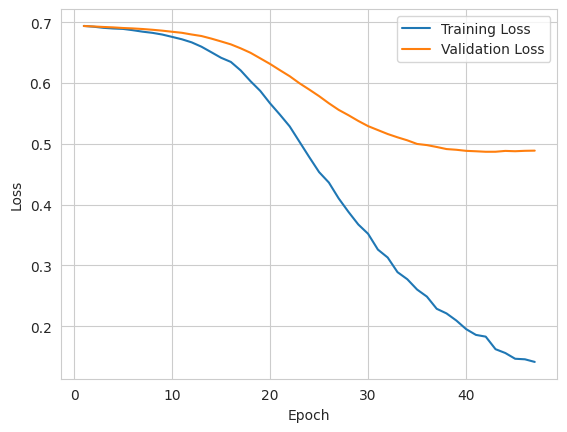

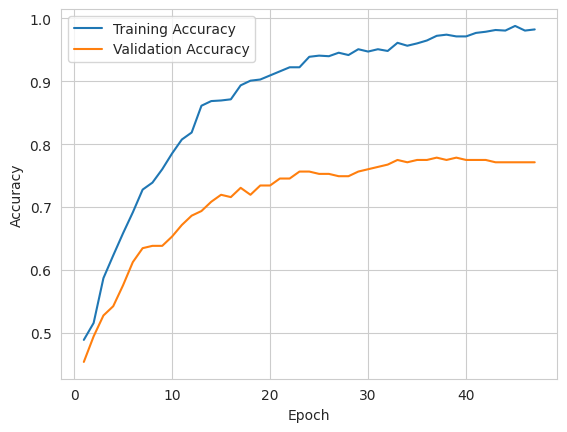

In [80]:
actual_epochs = len(history.history['loss'])
                     
plt.plot(range(1, actual_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, actual_epochs + 1), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Plot training and validation accuracy
plt.plot(range(1, actual_epochs + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, actual_epochs + 1), history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [81]:
loss, accuracy = nn_model.evaluate(X_test_tfidf.toarray(), y_test)

print('Loss: ', str(loss) , 'Accuracy: ', str(accuracy))

15/15 [==============================] - 0s 626us/step - loss: 0.4735 - accuracy: 0.7650
Loss:  0.47345730662345886 Accuracy:  0.7649667263031006


In [61]:
# Make predictions on the test set
probability_predictions = nn_model.predict(X_test_tfidf.toarray())

print("Predictions for the first 20 examples:")
for i in range(0, 20):
    if probability_predictions[i] > 0.5:
        print(f'Probability Value: {probability_predictions[i]}')
        print(f'Label: {y_test.to_numpy()[i]}')

Predictions for the first 20 examples:
Probability Value: [0.52890515]
Label: True
Probability Value: [0.5232281]
Label: False
Probability Value: [0.5261416]
Label: False
Probability Value: [0.51912105]
Label: False
Probability Value: [0.5219803]
Label: True
Probability Value: [0.53066665]
Label: True
Probability Value: [0.52875566]
Label: True
Probability Value: [0.5128733]
Label: False
Probability Value: [0.53281766]
Label: True
Probability Value: [0.5214266]
Label: False
Probability Value: [0.51945114]
Label: False
Probability Value: [0.5118874]
Label: False
Probability Value: [0.52295035]
Label: False
Probability Value: [0.52818906]
Label: True
Probability Value: [0.53545165]
Label: True
Probability Value: [0.5235302]
Label: True
Probability Value: [0.51233554]
Label: False
Probability Value: [0.52576816]
Label: True
Probability Value: [0.5270557]
Label: True
Probability Value: [0.52679056]
Label: False


In [ ]:
print('Review #1:\n')

print(X_test.to_numpy()[11])

goodReview = True if probability_predictions[11] >= .5 else False
    
print('\nPrediction: Is this a good review? {}\n'.format(goodReview))

print('Actual: Is this a good review? {}\n'.format(y_test.to_numpy()[11]))

In [ ]:
print('Review #2:\n')

print(X_test.to_numpy()[24])

goodReview = True if probability_predictions[24] >= .5 else False

print('\nPrediction: Is this a good review? {}\n'.format(goodReview)) 

print('Actual: Is this a good review? {}\n'.format(y_test.to_numpy()[24]))

In [ ]:
print('Review #3:\n')

print(X_test.to_numpy()[56])

goodReview = True if probability_predictions[56] >= .5 else False
    
print('\nPrediction: Is this a good review? {}\n'.format(goodReview))

print('Actual: Is this a good review? {}\n'.format(y_test.to_numpy()[56]))

In [ ]:
print('Review #4:\n')
print(X_test.to_numpy()[102])

goodReview = True if probability_predictions[102] >= .5 else False
    
print('\nPrediction: Is this a good review? {}\n'.format(goodReview))

print('Actual: Is this a good review? {}\n'.format(y_test.to_numpy()[102]))